<a href="https://colab.research.google.com/github/Armin-HassanzadehHassanabad/Car-Price-Prediction/blob/main/Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CarPrice_Assignment.csv to CarPrice_Assignment (6).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cars = pd.read_csv('CarPrice_Assignment.csv')

cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
pd.DataFrame(cars["CarName"])

,CarName
0,alfa-romero giulia
1,alfa-romero stelvio
2,alfa-romero Quadrifoglio
3,audi 100 ls
4,audi 100ls
...,...
200,volvo 145e (sw)
201,volvo 144ea
202,volvo 244dl
203,volvo 246


In [ ]:
CompanyName = cars['CarName'].apply(lambda i : i.split(' '))
CompanyName

,CarName
0,"[alfa-romero, giulia]"
1,"[alfa-romero, stelvio]"
2,"[alfa-romero, Quadrifoglio]"
3,"[audi, 100, ls]"
4,"[audi, 100ls]"
...,...
200,"[volvo, 145e, (sw)]"
201,"[volvo, 144ea]"
202,"[volvo, 244dl]"
203,"[volvo, 246]"


In [ ]:
CompanyName = cars['CarName'].apply(lambda x : x.split(' ')[0])
CompanyName

,CarName
0,alfa-romero
1,alfa-romero
2,alfa-romero
3,audi
4,audi
...,...
200,volvo
201,volvo
202,volvo
203,volvo


In [ ]:
cars.insert(3,"CompanyName",CompanyName)
cars.drop(['CarName'],axis=1,inplace=True)
cars.head()

,car_ID,symboling,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
cars.CompanyName.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [ ]:
cars.CompanyName = cars.CompanyName.str.lower()

In [ ]:
def replace_name(a,b):
    cars.CompanyName.replace(a,b,inplace=True)

replace_name('maxda','mazda')
replace_name('porcshce','porsche')
replace_name('toyouta','toyota')
replace_name('vokswagen','volkswagen')
replace_name('vw','volkswagen')

cars.CompanyName.unique()

/tmp/ipykernel_4914/1606685020.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars.CompanyName.replace(a,b,inplace=True)


array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

Text(0.5, 0, 'Continuous Variable')

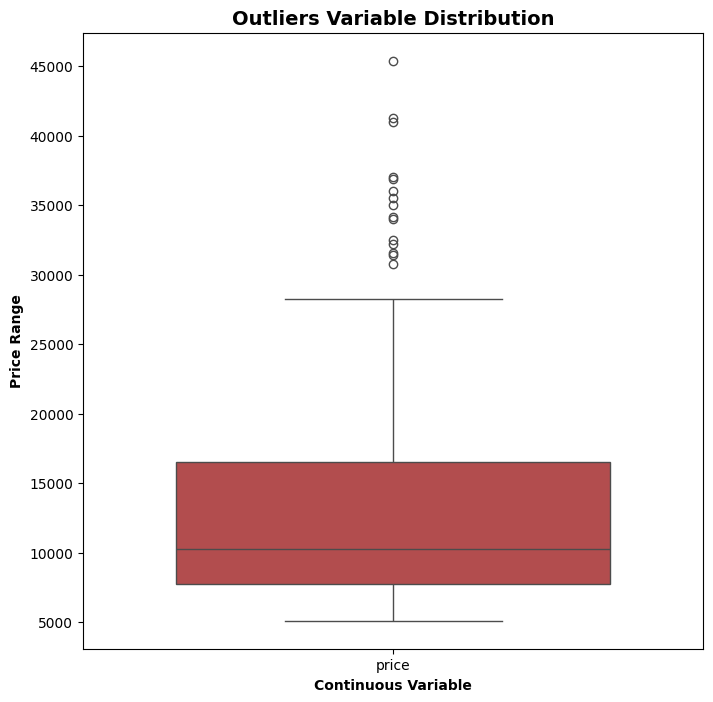

In [ ]:
outliers = ['price']
plt.rcParams['figure.figsize'] = [8,8]
sns.boxplot(data=cars[outliers], orient="v", palette="Set1" ,whis=1.5,saturation=0.5, width=0.7)
plt.title("Outliers Variable Distribution", fontsize = 14, fontweight = 'bold')
plt.ylabel("Price Range", fontweight = 'bold')
plt.xlabel("Continuous Variable", fontweight = 'bold')

/tmp/ipykernel_4914/113862094.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cars.price)


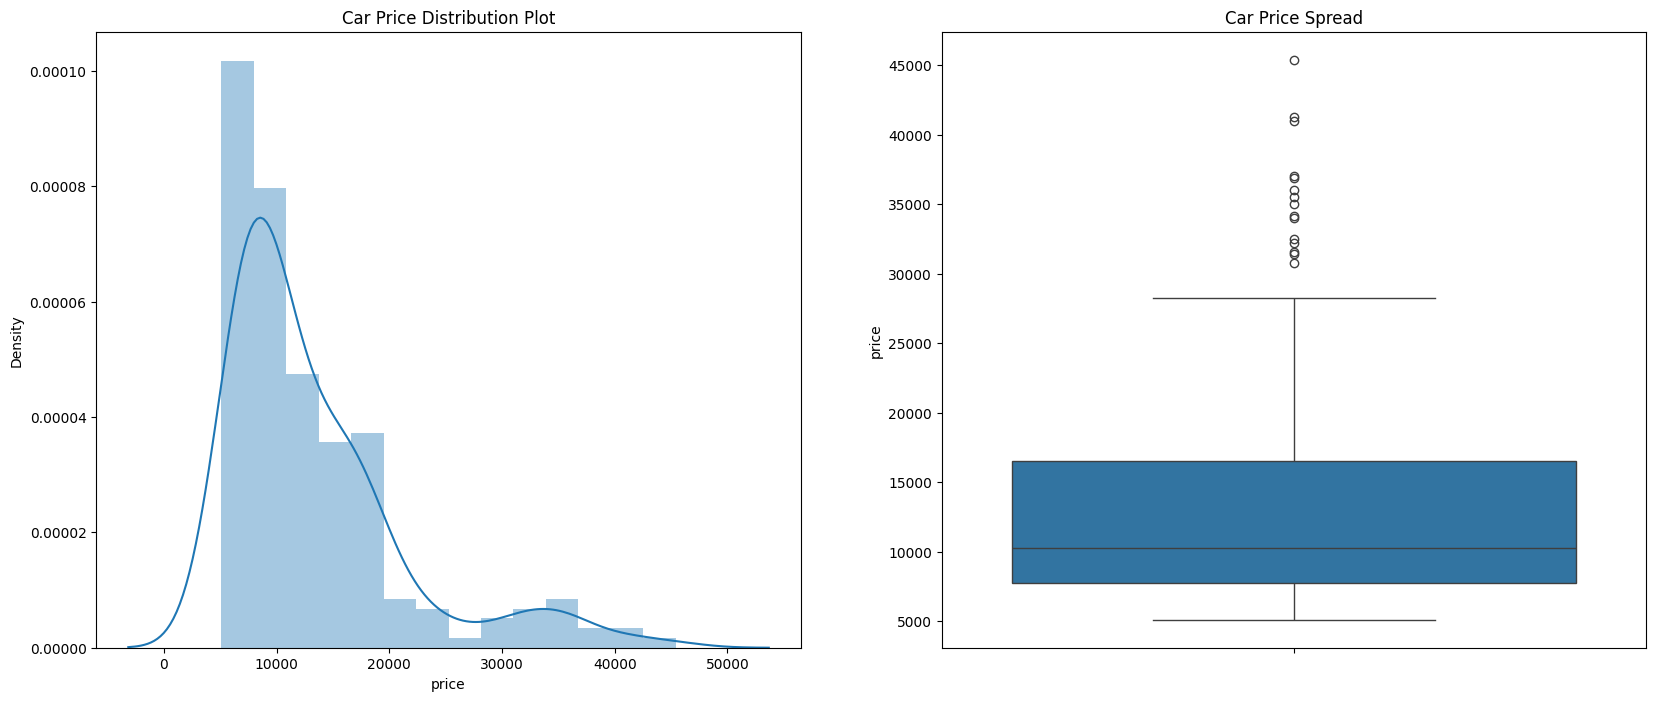

In [ ]:
plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
plt.title('Car Price Distribution Plot')
sns.distplot(cars.price)
plt.subplot(1,2,2)
plt.title('Car Price Spread')
sns.boxplot(y=cars.price)
plt.show()

In [ ]:
cat_col = cars.select_dtypes(include=['object']).columns
num_col = cars.select_dtypes(exclude=['object']).columns
df_cat = cars[cat_col]
df_num = cars[num_col]
df_cat

,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


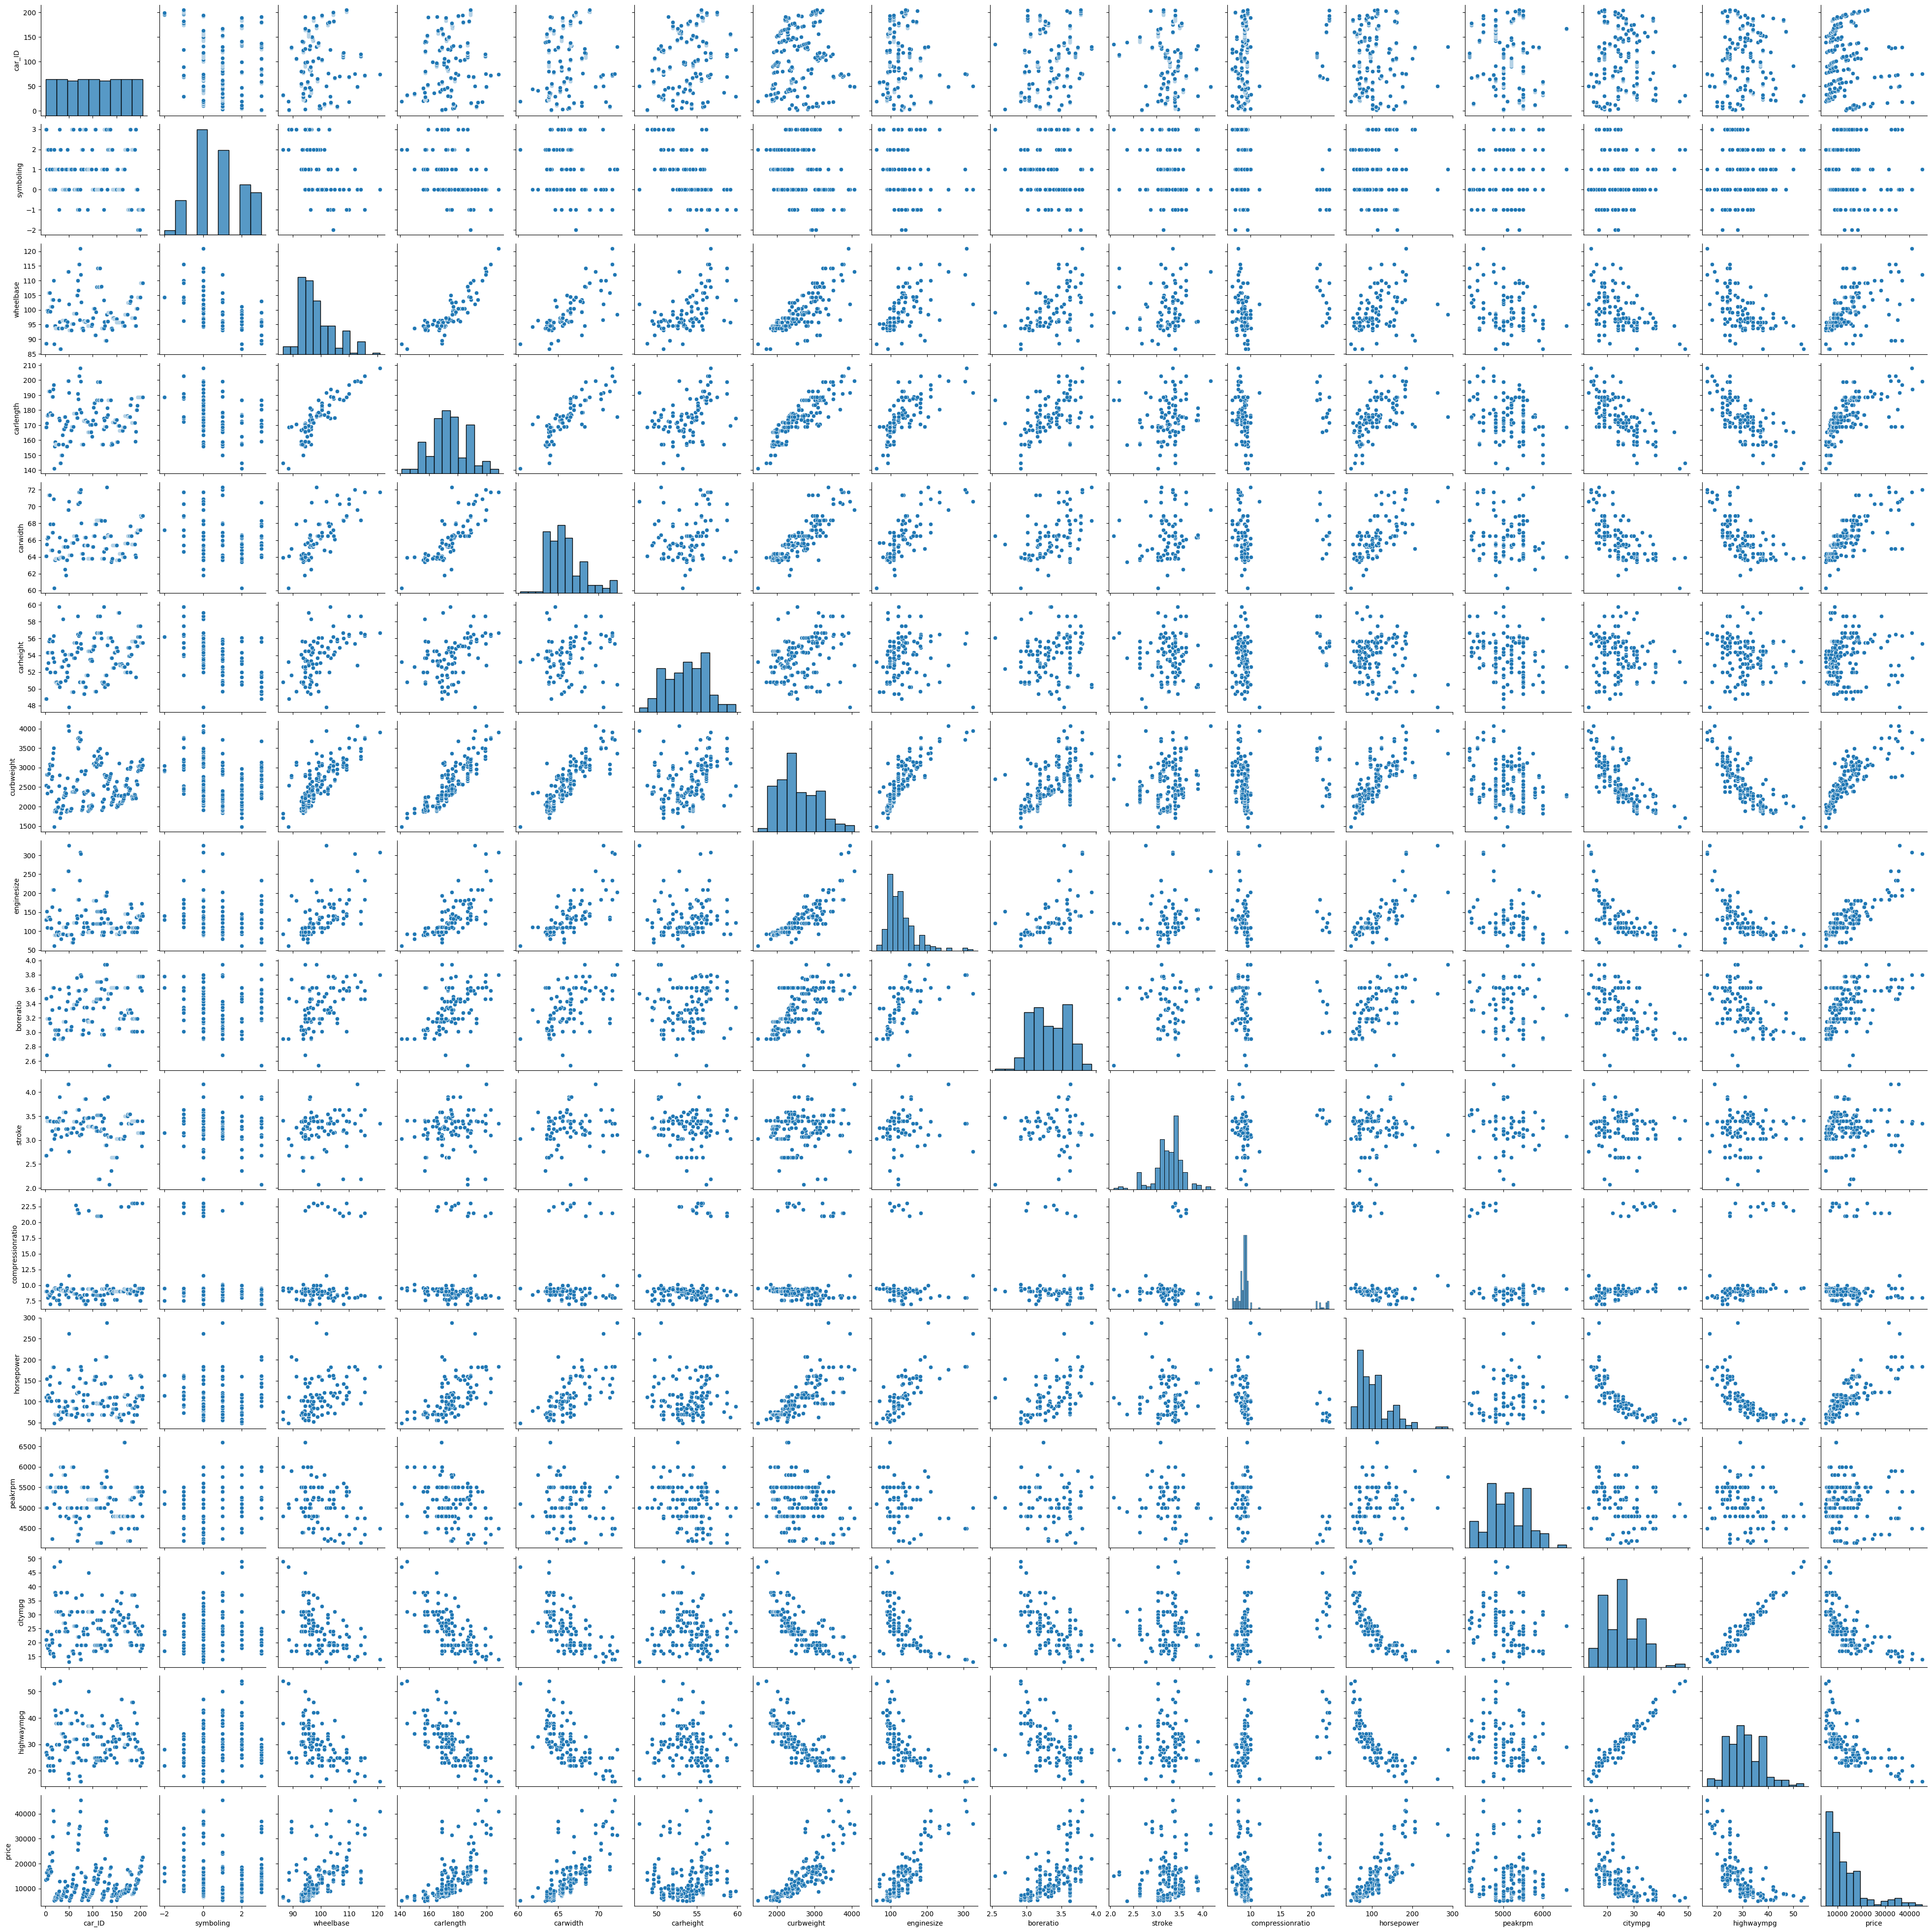

In [ ]:
ax = sns.pairplot(cars[num_col])

In [ ]:
num_col = cars.select_dtypes(exclude=['object']).columns
df_num = cars[num_col]

df_num.corr()
np.corrcoef(df_num['carlength'], df_num['carwidth'])
np.corrcoef(df_num['carlength'], df_num['carwidth'])[0,1]

np.float64(0.841118268481846)

In [ ]:
#Fuel economy
cars['fueleconomy'] = (0.55 * cars['citympg']) + (0.45 * cars['highwaympg'])

In [ ]:
table = cars.groupby(['CompanyName'])['price'].mean()
pd.DataFrame(table)

,price
CompanyName,
alfa-romero,15498.333333
audi,17859.166714
bmw,26118.750000
buick,33647.000000
chevrolet,6007.000000
dodge,7875.444444
honda,8184.692308
isuzu,8916.500000
jaguar,34600.000000


In [ ]:
temp = cars.copy()
temp = temp.merge(table.reset_index(), how='left',on='CompanyName')
temp

# price_x = actual price
# price_y = mean(price)

,car_ID,symboling,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price_x,fueleconomy,price_y
0,1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,13495.0,23.70,15498.333333
1,2,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,16500.0,23.70,15498.333333
2,3,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,2.68,3.47,9.0,154,5000,19,26,16500.0,22.15,15498.333333
3,4,2,audi,gas,std,four,sedan,fwd,front,99.8,...,3.19,3.40,10.0,102,5500,24,30,13950.0,26.70,17859.166714
4,5,2,audi,gas,std,four,sedan,4wd,front,99.4,...,3.19,3.40,8.0,115,5500,18,22,17450.0,19.80,17859.166714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo,gas,std,four,sedan,rwd,front,109.1,...,3.78,3.15,9.5,114,5400,23,28,16845.0,25.25,18063.181818
201,202,-1,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,3.78,3.15,8.7,160,5300,19,25,19045.0,21.70,18063.181818
202,203,-1,volvo,gas,std,four,sedan,rwd,front,109.1,...,3.58,2.87,8.8,134,5500,18,23,21485.0,20.25,18063.181818
203,204,-1,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,3.01,3.40,23.0,106,4800,26,27,22470.0,26.45,18063.181818


In [ ]:
# cars['price'] = cars['price'].astype('int')
temp = cars.copy()
table = temp.groupby(['CompanyName'])['price'].mean()
temp = temp.merge(table.reset_index(), how='left',on='CompanyName')

bins = [0,10000,20000,40000]
cars_bin=['Budget','Medium','Highend']
cars['carsrange'] = pd.cut(temp['price_y'],bins, labels=cars_bin)
cars.head()

,car_ID,symboling,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,fueleconomy,carsrange
0,1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,13495.0,23.70,Medium
1,2,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,16500.0,23.70,Medium
2,3,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,2.68,3.47,9.0,154,5000,19,26,16500.0,22.15,Medium
3,4,2,audi,gas,std,four,sedan,fwd,front,99.8,...,3.19,3.40,10.0,102,5500,24,30,13950.0,26.70,Medium
4,5,2,audi,gas,std,four,sedan,4wd,front,99.4,...,3.19,3.40,8.0,115,5500,18,22,17450.0,19.80,Medium


In [ ]:
cars_lr = cars[['price','fueltype', 'aspiration', 'carbody', 'drivewheel','wheelbase',
'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'boreratio',
'horsepower', 'fueleconomy' ,'citympg','highwaympg', 'carlength','carwidth', 'carsrange']]
cars_lr.head()

,price,fueltype,aspiration,carbody,drivewheel,wheelbase,curbweight,enginetype,cylindernumber,enginesize,boreratio,horsepower,fueleconomy,citympg,highwaympg,carlength,carwidth,carsrange
0,13495.0,gas,std,convertible,rwd,88.6,2548,dohc,four,130,3.47,111,23.70,21,27,168.8,64.1,Medium
1,16500.0,gas,std,convertible,rwd,88.6,2548,dohc,four,130,3.47,111,23.70,21,27,168.8,64.1,Medium
2,16500.0,gas,std,hatchback,rwd,94.5,2823,ohcv,six,152,2.68,154,22.15,19,26,171.2,65.5,Medium
3,13950.0,gas,std,sedan,fwd,99.8,2337,ohc,four,109,3.19,102,26.70,24,30,176.6,66.2,Medium
4,17450.0,gas,std,sedan,4wd,99.4,2824,ohc,five,136,3.19,115,19.80,18,22,176.6,66.4,Medium


In [ ]:
# Defining the map function
def dummies(x,df):
    temp = pd.get_dummies(df[x], drop_first = True)
    temp = temp.astype(int)
    df = pd.concat([df, temp], axis = 1)
    df.drop([x], axis = 1, inplace = True)
    return df

# Applying the function to the cars_lr
cars_lr = dummies('fueltype',cars_lr)
cars_lr = dummies('aspiration',cars_lr)
cars_lr = dummies('carbody',cars_lr)
cars_lr = dummies('drivewheel',cars_lr)
cars_lr = dummies('enginetype',cars_lr)
cars_lr = dummies('cylindernumber',cars_lr)
cars_lr = dummies('carsrange',cars_lr)

In [ ]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(cars_lr, train_size = 0.7, test_size = 0.3, random_state = 100)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_vars = ['wheelbase', 'curbweight', 'enginesize', 'boreratio', 'horsepower','fueleconomy','carlength','carwidth','citympg','highwaympg','price']
df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

In [ ]:
df_train.head()

,price,wheelbase,curbweight,enginesize,boreratio,horsepower,fueleconomy,citympg,highwaympg,carlength,...,ohcv,rotor,five,four,six,three,twelve,two,Medium,Highend
122,0.068818,0.244828,0.272692,0.139623,0.230159,0.083333,0.530864,0.500000,0.567568,0.426016,...,0,0,0,1,0,0,0,0,0,0
125,0.466890,0.272414,0.500388,0.339623,1.000000,0.395833,0.213992,0.166667,0.270270,0.452033,...,0,0,0,1,0,0,0,0,0,1
166,0.122110,0.272414,0.314973,0.139623,0.444444,0.266667,0.344307,0.361111,0.324324,0.448780,...,0,0,0,1,0,0,0,0,0,0
1,0.314446,0.068966,0.411171,0.260377,0.626984,0.262500,0.244170,0.222222,0.270270,0.450407,...,0,0,0,1,0,0,0,0,1,0
199,0.382131,0.610345,0.647401,0.260377,0.746032,0.475000,0.122085,0.111111,0.135135,0.775610,...,0,0,0,1,0,0,0,0,1,0


In [ ]:
df_test[num_vars] = scaler.transform(df_test[num_vars])
df_test.head()

,price,wheelbase,curbweight,enginesize,boreratio,horsepower,fueleconomy,citympg,highwaympg,carlength,...,ohcv,rotor,five,four,six,three,twelve,two,Medium,Highend
160,0.072382,0.313793,0.235066,0.139623,0.404762,0.091667,0.747599,0.694444,0.810811,0.409756,...,0,0,0,1,0,0,0,0,0,0
186,0.093295,0.368966,0.305275,0.181132,0.404762,0.154167,0.421125,0.388889,0.459459,0.497561,...,0,0,0,1,0,0,0,0,1,0
59,0.102964,0.420690,0.347944,0.230189,0.563492,0.150000,0.381344,0.361111,0.405405,0.596748,...,0,0,0,1,0,0,0,0,1,0
165,0.115479,0.272414,0.301396,0.139623,0.444444,0.266667,0.344307,0.361111,0.324324,0.448780,...,0,0,0,1,0,0,0,0,0,0
140,0.068652,0.231034,0.291699,0.177358,0.746032,0.104167,0.368999,0.361111,0.378378,0.263415,...,0,0,0,1,0,0,0,0,0,0


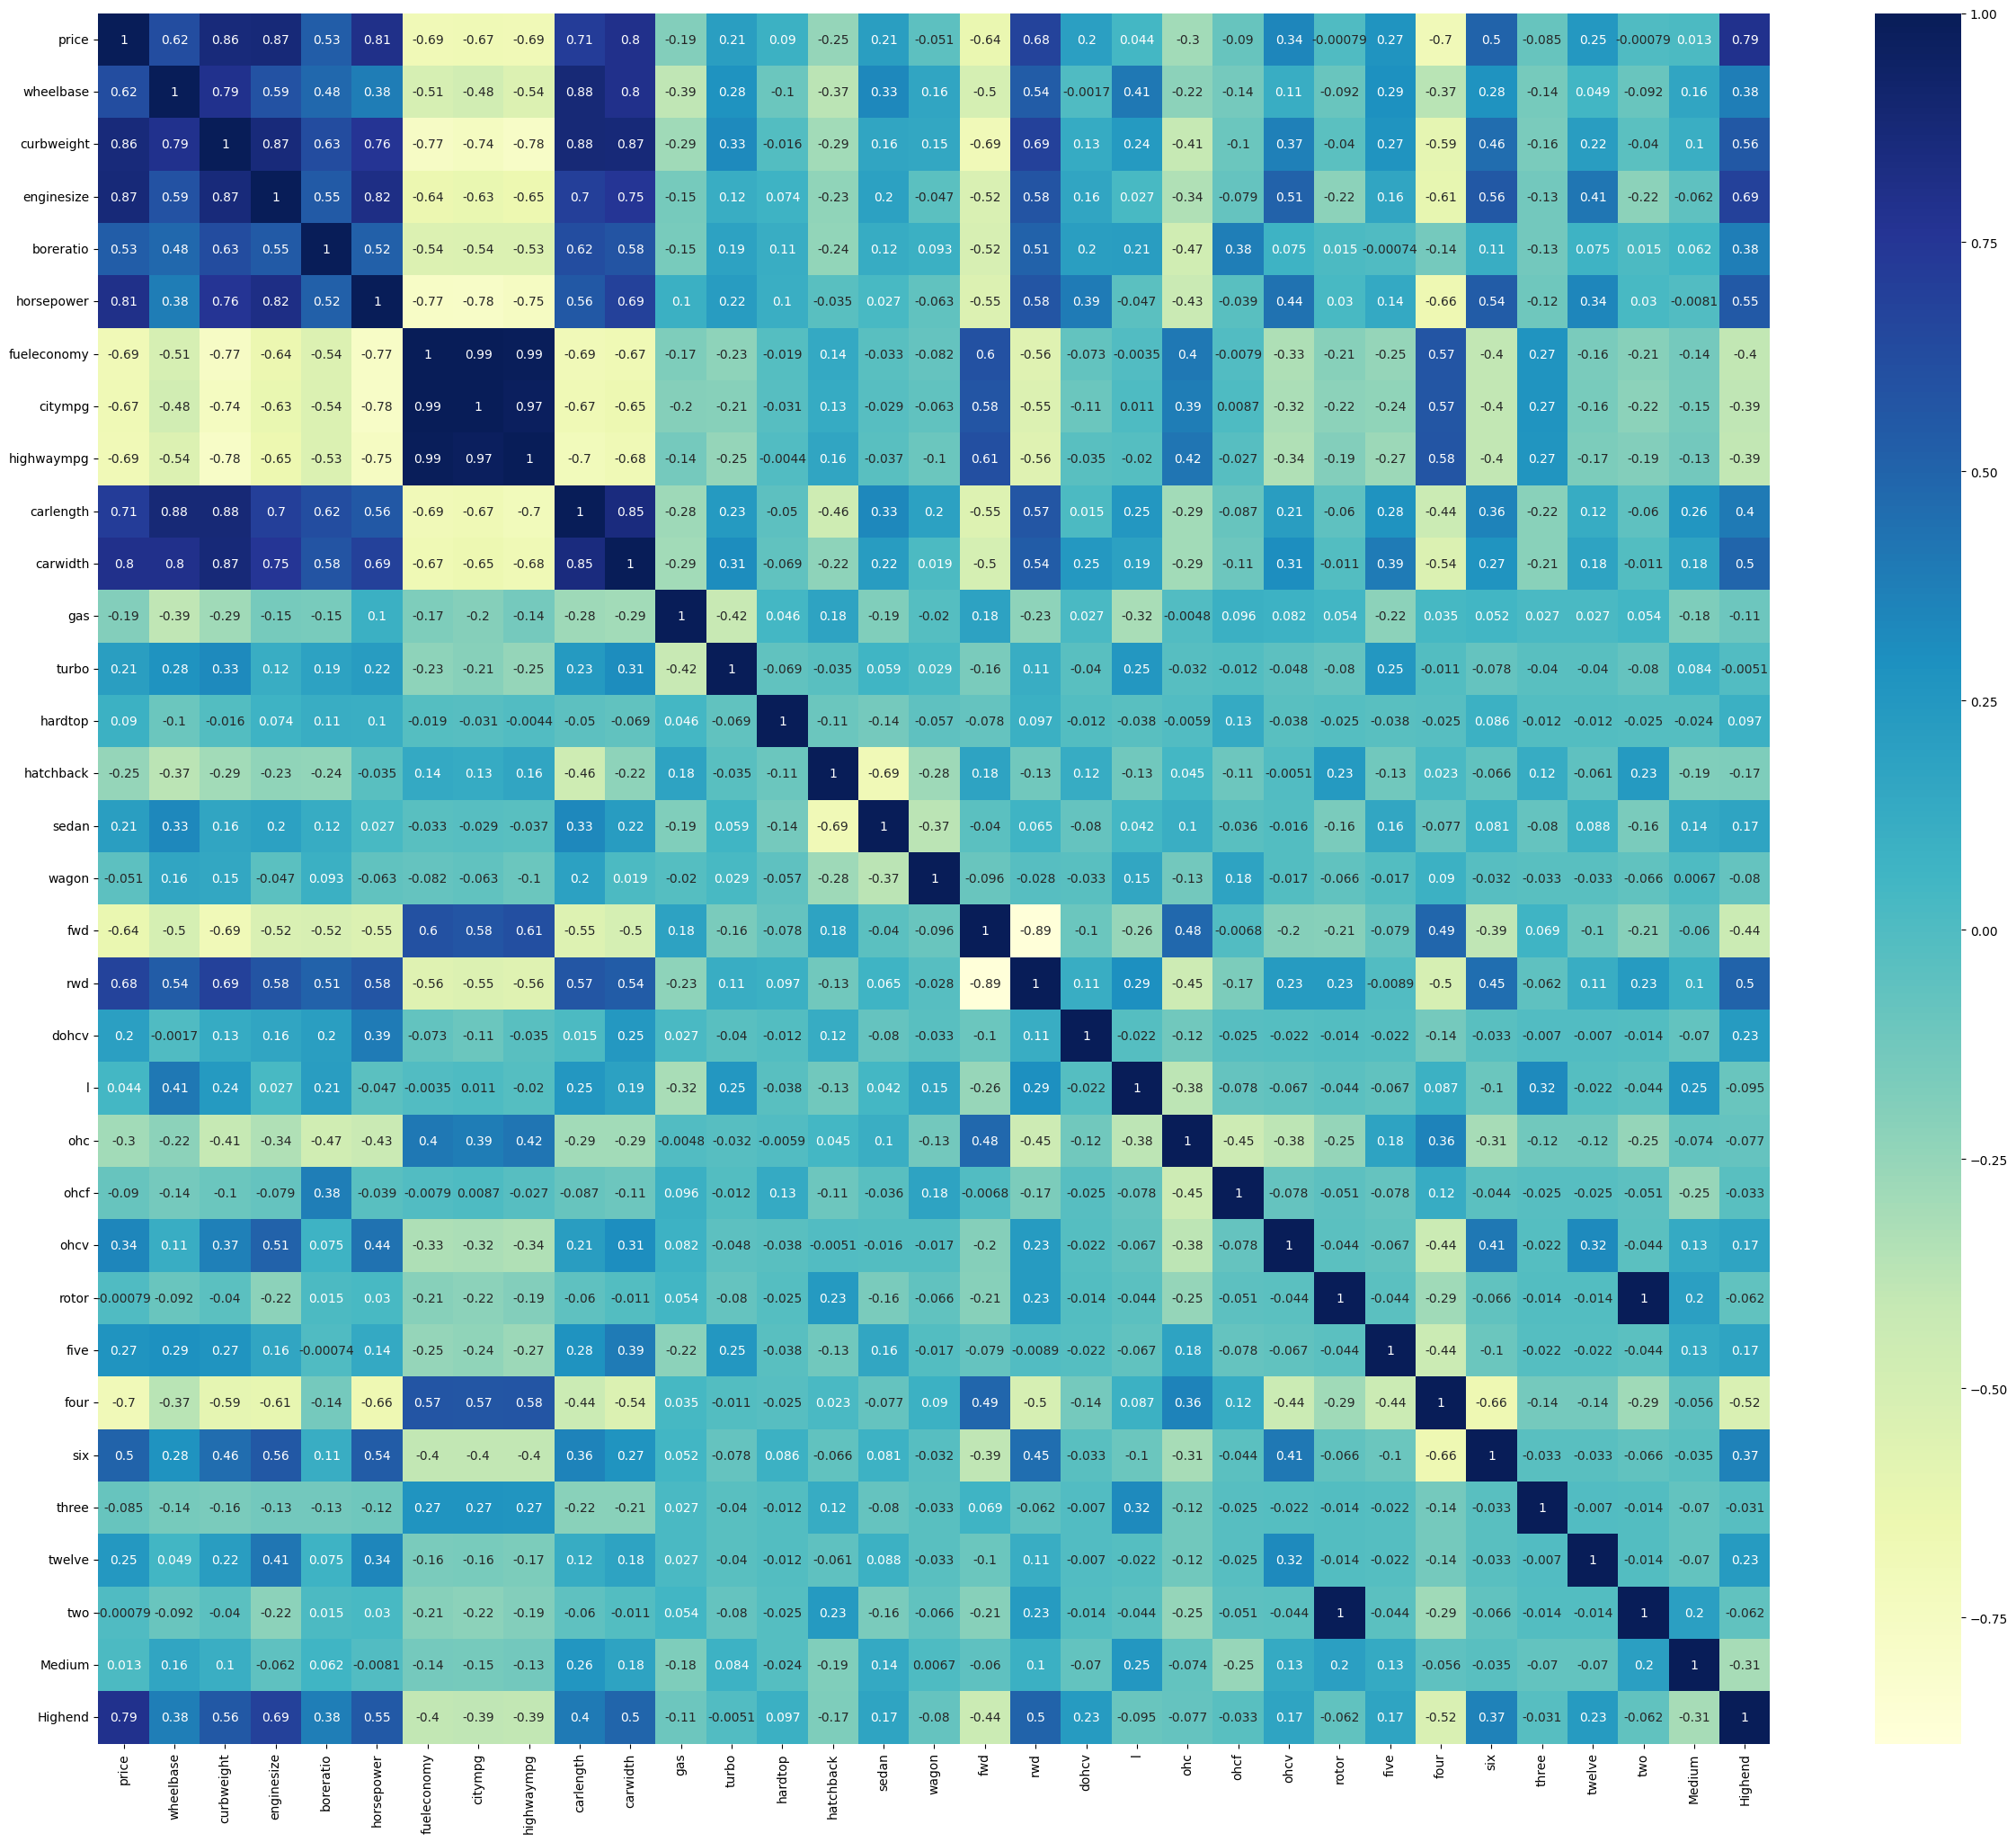

In [ ]:
plt.figure(figsize = (30, 25))
sns.heatmap(df_train.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [ ]:
y_train = df_train.pop('price')
X_train = df_train

In [ ]:
import statsmodels.api as sm
X_train_1 = X_train['horsepower']
X_train_1c = sm.add_constant(X_train_1)
# Create a first fitted model
lr_1 = sm.OLS(y_train, X_train_1c).fit()
lr_1.params

,0
const,-0.019484
horsepower,1.050556


In [ ]:
# Print a summary of the linear regression model obtained
print(lr_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     261.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           6.04e-34
Time:                        02:57:54   Log-Likelihood:                 91.997
No. Observations:                 143   AIC:                            -180.0
Df Residuals:                     141   BIC:                            -174.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0195      0.018     -1.068      0.2

In [ ]:
X_train_2 = X_train[['horsepower', 'curbweight']]
X_train_2c = sm.add_constant(X_train_2)
# Create a second fitted model
lr_2 = sm.OLS(y_train, X_train_2c).fit()
lr_2.params

,0
const,-0.132349
horsepower,0.466601
curbweight,0.602138


In [ ]:
print(lr_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     274.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           3.34e-49
Time:                        02:57:54   Log-Likelihood:                 130.96
No. Observations:                 143   AIC:                            -255.9
Df Residuals:                     140   BIC:                            -247.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1323      0.018     -7.401      0.0

In [ ]:
X_train_3 = X_train[['horsepower', 'curbweight', 'enginesize']]
# Add a constant
X_train_3c = sm.add_constant(X_train_3)
# Create a third fitted model
lr_3 = sm.OLS(y_train, X_train_3c).fit()
lr_3.params

,0
const,-0.126942
horsepower,0.298222
curbweight,0.402044
enginesize,0.474331


In [ ]:
print(lr_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     209.7
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           2.16e-51
Time:                        02:57:54   Log-Likelihood:                 139.18
No. Observations:                 143   AIC:                            -270.4
Df Residuals:                     139   BIC:                            -258.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1269      0.017     -7.469      0.0

In [ ]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LinearRegression #predict #dummy #ffill, bfill
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
lm = LinearRegression()
lm.fit(X_train,y_train)
rfe = RFE(lm, n_features_to_select = 10)
rfe = rfe.fit(X_train, y_train)
# RFE (MODEL, Number of feature to select)

In [ ]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('wheelbase', np.False_, np.int64(3)),
 ('curbweight', np.True_, np.int64(1)),
 ('enginesize', np.False_, np.int64(14)),
 ('boreratio', np.False_, np.int64(11)),
 ('horsepower', np.True_, np.int64(1)),
 ('fueleconomy', np.True_, np.int64(1)),
 ('citympg', np.False_, np.int64(16)),
 ('highwaympg', np.False_, np.int64(8)),
 ('carlength', np.False_, np.int64(12)),
 ('carwidth', np.True_, np.int64(1)),
 ('gas', np.False_, np.int64(19)),
 ('turbo', np.False_, np.int64(22)),
 ('hardtop', np.False_, np.int64(2)),
 ('hatchback', np.True_, np.int64(1)),
 ('sedan', np.True_, np.int64(1)),
 ('wagon', np.True_, np.int64(1)),
 ('fwd', np.False_, np.int64(17)),
 ('rwd', np.False_, np.int64(18)),
 ('dohcv', np.True_, np.int64(1)),
 ('l', np.False_, np.int64(20)),
 ('ohc', np.False_, np.int64(7)),
 ('ohcf', np.False_, np.int64(9)),
 ('ohcv', np.False_, np.int64(10)),
 ('rotor', np.False_, np.int64(21)),
 ('five', np.False_, np.int64(6)),
 ('four', np.False_, np.int64(4)),
 ('six', np.False_, np.int64

In [ ]:
X_train.columns[rfe.support_]

Index(['curbweight', 'horsepower', 'fueleconomy', 'carwidth', 'hatchback',
       'sedan', 'wagon', 'dohcv', 'twelve', 'Highend'],
      dtype='object')

In [ ]:
X_train_rfe = X_train[X_train.columns[rfe.support_]]
X_train_rfe.head()

,curbweight,horsepower,fueleconomy,carwidth,hatchback,sedan,wagon,dohcv,twelve,Highend
122,0.272692,0.083333,0.530864,0.291667,0,1,0,0,0,0
125,0.500388,0.395833,0.213992,0.666667,1,0,0,0,0,1
166,0.314973,0.266667,0.344307,0.308333,1,0,0,0,0,0
1,0.411171,0.262500,0.244170,0.316667,0,0,0,0,0,0
199,0.647401,0.475000,0.122085,0.575000,0,0,1,0,0,0


In [ ]:
vif = pd.DataFrame()
vif['Features'] = X_train_rfe.columns
# pythonic
vif['VIF'] = [variance_inflation_factor(X_train_rfe.values, i) for i in range(X_train_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif
#reset_index()

,Features,VIF
0,curbweight,39.50
3,carwidth,36.38
1,horsepower,12.58
5,sedan,9.69
4,hatchback,6.91
2,fueleconomy,6.77
6,wagon,3.33
9,Highend,1.87
7,dohcv,1.50
8,twelve,1.20


In [ ]:
def build_model(X,y):
    X = sm.add_constant(X)
    lm = sm.OLS(y,X).fit()  # fitting the model
    print(lm.summary())
    return X

def checkVIF(X):
    vif = pd.DataFrame()
    vif['Features'] = X.columns

    #pythonic
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    return(vif)

checkVIF(X_train_rfe)

,Features,VIF
0,curbweight,39.50
3,carwidth,36.38
1,horsepower,12.58
5,sedan,9.69
4,hatchback,6.91
2,fueleconomy,6.77
6,wagon,3.33
9,Highend,1.87
7,dohcv,1.50
8,twelve,1.20


In [ ]:
X_train_new = build_model(X_train_rfe,y_train)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     172.1
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.29e-70
Time:                        02:57:54   Log-Likelihood:                 205.85
No. Observations:                 143   AIC:                            -389.7
Df Residuals:                     132   BIC:                            -357.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0947      0.042     -2.243      

In [ ]:
X_train_new = X_train_rfe.drop(["twelve"], axis = 1)

In [ ]:
X_train_new = build_model(X_train_new,y_train)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     187.9
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           4.25e-71
Time:                        02:57:54   Log-Likelihood:                 204.17
No. Observations:                 143   AIC:                            -388.3
Df Residuals:                     133   BIC:                            -358.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0764      0.041     -1.851      

In [ ]:
X_train_new = X_train_rfe.drop(["twelve", "fueleconomy"], axis = 1)

In [ ]:
X_train_new = build_model(X_train_new,y_train)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     209.5
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           7.86e-72
Time:                        02:57:54   Log-Likelihood:                 203.07
No. Observations:                 143   AIC:                            -388.1
Df Residuals:                     134   BIC:                            -361.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0305      0.026     -1.165      0.2

In [ ]:
checkVIF(X_train_new)

,Features,VIF
0,const,26.90
1,curbweight,8.10
5,sedan,6.07
4,hatchback,5.63
3,carwidth,5.14
2,horsepower,3.61
6,wagon,3.58
8,Highend,1.63
7,dohcv,1.46


In [ ]:
X_train_new = X_train_new.drop(["curbweight"], axis = 1)
X_train_new = build_model(X_train_new,y_train)
checkVIF(X_train_new)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     215.9
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           4.70e-70
Time:                        02:57:54   Log-Likelihood:                 195.77
No. Observations:                 143   AIC:                            -375.5
Df Residuals:                     135   BIC:                            -351.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0319      0.027     -1.161      0.2

,Features,VIF
0,const,26.89
4,sedan,6.06
3,hatchback,5.54
5,wagon,3.47
1,horsepower,2.50
2,carwidth,2.22
7,Highend,1.56
6,dohcv,1.21


In [ ]:
X_train_new = build_model(X_train_new,y_train)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     215.9
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           4.70e-70
Time:                        02:57:54   Log-Likelihood:                 195.77
No. Observations:                 143   AIC:                            -375.5
Df Residuals:                     135   BIC:                            -351.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0319      0.027     -1.161      0.2

In [ ]:
lm = sm.OLS(y_train,X_train_new).fit()
y_train_price = lm.predict(X_train_new)

/tmp/ipykernel_4914/4182825274.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_train - y_train_price), bins = 20)


Text(0.5, 0, 'Errors')

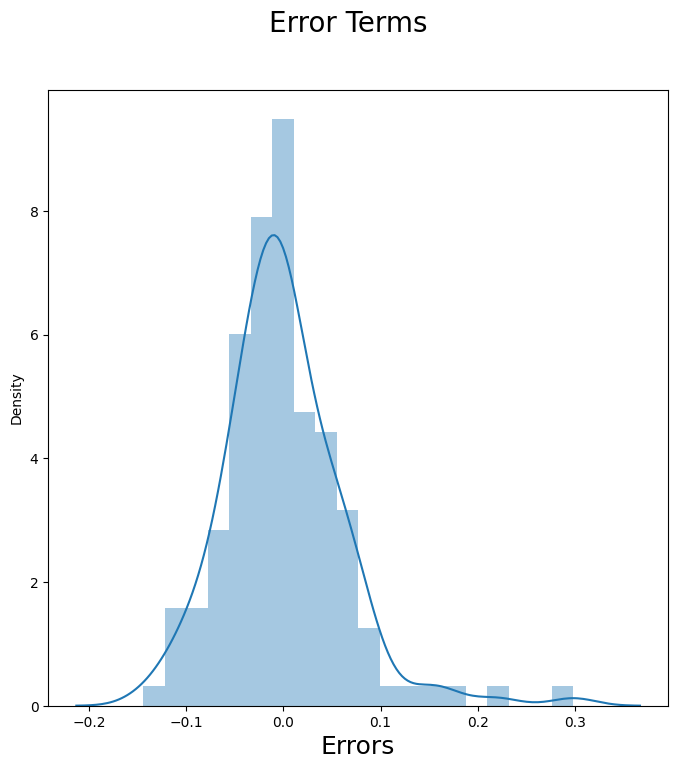

In [ ]:
# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot((y_train - y_train_price), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)
plt.xlabel('Errors', fontsize = 18)

In [ ]:
y_test = df_test.pop('price')
X_test = df_test

In [ ]:
X_train_new = X_train_new.drop('const',axis=1)
X_test_new = X_test[X_train_new.columns]
X_test_new = sm.add_constant(X_test_new)

In [ ]:
# Making predictions
y_pred = lm.predict(X_test_new)

In [ ]:
from sklearn.metrics import r2_score # Overfitting
r2_score(y_test, y_pred)

0.915385289472592

In [ ]:
r2_score(y_train, y_train_price) #stat

0.9179941601121561

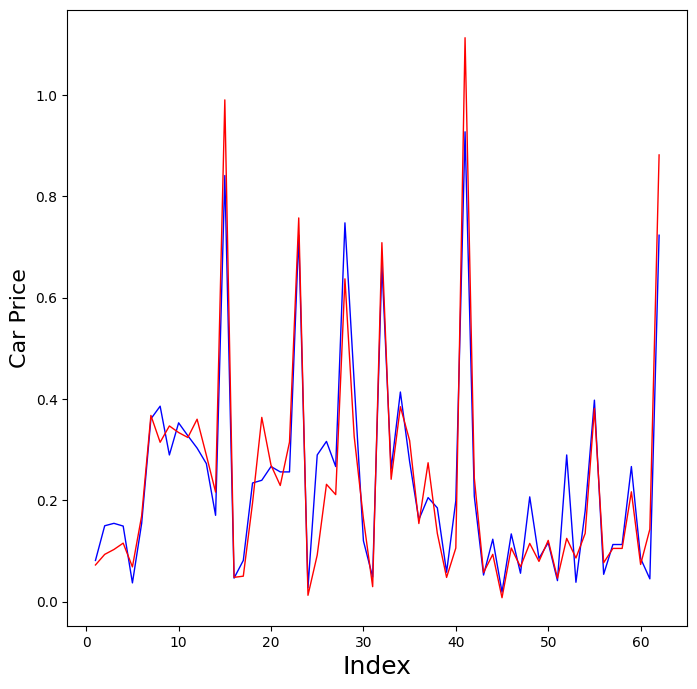

In [ ]:
c = [i for i in range(1,63,1)]
d = [i for i in range(1,63,1)]
plt.plot(c, y_pred, color="blue", linewidth=1, linestyle="-")
plt.plot(d, y_test, color="red", linewidth=1, linestyle="-")
plt.xlabel('Index', fontsize=18)
plt.ylabel('Car Price', fontsize=16)
plt.show()

Text(0, 0.5, 'y_pred')

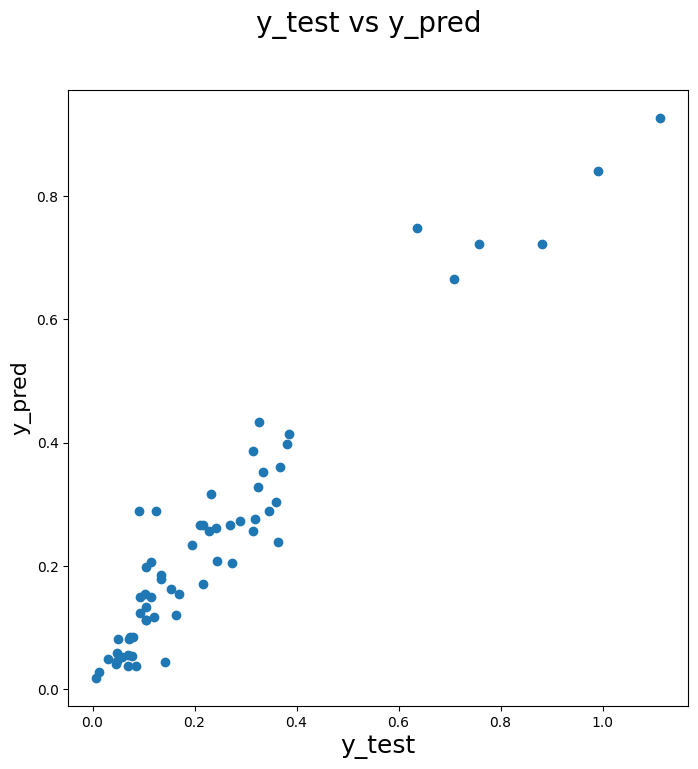

In [ ]:
fig = plt.figure()
plt.scatter(y_test,y_pred)
fig.suptitle('y_test vs y_pred', fontsize=20)
plt.xlabel('y_test', fontsize=18)
plt.ylabel('y_pred', fontsize=16)

In [ ]:
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     215.9
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           4.70e-70
Time:                        03:00:13   Log-Likelihood:                 195.77
No. Observations:                 143   AIC:                            -375.5
Df Residuals:                     135   BIC:                            -351.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0319      0.027     -1.161      0.2

**Thank you!**